In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Load dataset
df = pd.read_excel('/content/World_development_mesurement.xlsx')
df

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,NaN,NaN,NaN,Turks and Caicos Islands,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,32427,0.911,NaN,NaN
2700,0.013,46.4%,NaN,United States,5.0,4.0,2132446.0,"$16,244,600,000,000",0.179,"$8,895",...,76.0,1.0,1,0.196,0.667,0.136,313873685,0.811,"$200,092,000,000","$126,573,000,000"
2701,0.015,41.9%,NaN,Uruguay,7.0,85.0,NaN,"$50,004,354,667",0.089,"$1,308",...,74.0,1.5,1,0.220,0.639,0.140,3395253,0.948,"$2,222,000,000","$1,028,000,000"
2702,0.020,61.9%,NaN,"Venezuela, RB",144.0,180.0,NaN,"$381,286,223,859",0.046,$593,...,72.0,1.0,1,0.288,0.652,0.060,29954782,0.889,"$904,000,000","$3,202,000,000"


In [ ]:
# Convert 'Business Tax Rate' from object to numeric
df['Business Tax Rate'] = df['Business Tax Rate'].str.replace('%', '').astype(float) / 100

# Convert 'GDP', 'Health Exp/Capita', 'Tourism Inbound', 'Tourism Outbound' from object to numeric
# These columns contain '$' and ',' characters that need to be removed.
for col in ['GDP', 'Health Exp/Capita', 'Tourism Inbound', 'Tourism Outbound']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Display info after conversion to verify data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   float64
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   float64
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   float64
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   float64
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   float64
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   float64
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [ ]:
df.describe()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
count,2585.000000,1423.000000,2.125000e+03,1718.000000,185.000000,1.785000e+03,2.494000e+03,2395.000000,2395.000000,1416.000000,...,2568.000000,2537.000000,2704.0,2484.000000,2484.000000,2484.000000,2.704000e+03,2678.000000,2.336000e+03,2.233000e+03
mean,0.022715,0.489669,1.423071e+05,39.999418,94.875676,7.723684e+04,2.638540e+11,0.064170,801.397077,302.068503,...,66.461838,0.578124,1.0,0.303051,0.623481,0.073465,3.145729e+07,0.562953,4.939320e+09,4.729435e+09
std,0.011338,0.409541,6.159288e+05,57.318588,54.791906,2.599239e+05,1.129910e+12,0.026325,1473.448036,273.299686,...,9.390217,0.474647,0.0,0.106577,0.069660,0.049541,1.242894e+08,0.245897,1.385098e+10,1.326774e+10
min,0.007000,0.082000,7.000000e+00,1.000000,1.000000,8.000000e+00,6.310127e+07,0.008000,2.000000,12.000000,...,37.000000,0.000000,1.0,0.118000,0.474000,0.003000,1.887600e+04,0.082000,7.000000e+05,2.000000e+05
25%,0.013000,0.324000,1.360000e+03,13.000000,48.000000,3.737000e+03,3.539042e+09,0.046000,50.000000,156.000000,...,61.000000,0.100000,1.0,0.204750,0.559000,0.033000,8.783360e+05,0.356000,1.250000e+08,1.100000e+08
50%,0.020000,0.410000,8.529000e+03,26.000000,94.000000,1.433800e+04,1.507975e+10,0.061000,193.000000,239.000000,...,69.000000,0.500000,1.0,0.299500,0.642500,0.052000,5.800324e+06,0.560000,6.885000e+08,4.560000e+08
75%,0.031000,0.515500,5.910800e+04,45.000000,142.000000,4.185200e+04,1.102047e+11,0.079000,665.000000,344.750000,...,73.250000,0.900000,1.0,0.402000,0.676000,0.112000,2.014089e+07,0.765000,3.601500e+09,2.842000e+09
max,0.053000,3.391000,8.286892e+06,694.000000,189.000000,2.727728e+06,1.624460e+13,0.225000,9908.000000,2600.000000,...,88.000000,2.900000,1.0,0.500000,0.858000,0.244000,1.350695e+09,1.000000,2.000920e+11,1.265730e+11


In [ ]:
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {len(duplicate_rows)}")

if not duplicate_rows.empty:
    print("\nFirst 5 duplicate rows:")
    print(duplicate_rows.head())

Number of duplicate rows: 0


In [ ]:
#missing values
missing_values_count = df.isnull().sum()
missing_values_percentage = (df.isnull().sum() / len(df)) * 100

print("Number of Missing Values per Column:\n", missing_values_count)
print("\nPercentage of Missing Values per Column:\n", missing_values_percentage)

Number of Missing Values per Column:
 Birth Rate                 119
Business Tax Rate         1281
CO2 Emissions              579
Country                      0
Days to Start Business     986
Ease of Business          2519
Energy Usage               919
GDP                        210
Health Exp % GDP           309
Health Exp/Capita          309
Hours to do Tax           1288
Infant Mortality Rate      260
Internet Usage             173
Lending Interest           824
Life Expectancy Female     136
Life Expectancy Male       136
Mobile Phone Usage         167
Number of Records            0
Population 0-14            220
Population 15-64           220
Population 65+             220
Population Total             0
Population Urban            26
Tourism Inbound            368
Tourism Outbound           471
dtype: int64

Percentage of Missing Values per Column:
 Birth Rate                 4.400888
Business Tax Rate         47.374260
CO2 Emissions             21.412722
Country                

In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Birth Rate                0
Business Tax Rate         0
CO2 Emissions             0
Country                   0
Days to Start Business    0
Ease of Business          0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Hours to do Tax           0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Number of Records         0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64


In [ ]:
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after categorical imputation:")
print(df.isnull().sum())

Missing values after categorical imputation:
Birth Rate                0
Business Tax Rate         0
CO2 Emissions             0
Country                   0
Days to Start Business    0
Ease of Business          0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Hours to do Tax           0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Number of Records         0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# --- Code to define df_processed (moved from cell 671c270d) ---
# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the 'Country' column
encoded_categorical_data = ohe.fit_transform(df[['Country']])

# Create a DataFrame from the encoded data
df_encoded_categorical = pd.DataFrame(encoded_categorical_data, columns=ohe.get_feature_names_out(['Country']))

# Drop the original 'Country' column from the main DataFrame
df_numerical = df.drop(columns=['Country'])

# Concatenate the numerical DataFrame with the one-hot encoded categorical DataFrame
df_processed = pd.concat([df_numerical, df_encoded_categorical], axis=1)
# --- End of code to define df_processed ---


# Identify numerical columns in df_processed
numerical_cols_processed = df_processed.select_dtypes(include=[np.number]).columns.tolist()

# Dictionary to store outliers for each column
outliers = {}

for col in numerical_cols_processed:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    col_outliers = df_processed[(df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)][col]
    if not col_outliers.empty:
        outliers[col] = col_outliers

if outliers:
    print("Outliers detected in the following columns:")
    for col, vals in outliers.items():
        print(f"\nColumn: {col} ({len(vals)} outliers)")
        print(vals.head()) # Display first 5 outliers for each column
else:
    print("No significant outliers detected in numerical columns using the IQR method.")

Outliers detected in the following columns:

Column: Business Tax Rate (451 outliers)
1040    0.769
1042    0.757
1043    0.171
1045    2.797
1047    0.657
Name: Business Tax Rate, dtype: float64

Column: CO2 Emissions (176 outliers)
43     368611.0
60    3405180.0
63    1186663.0
65    1219589.0
68     447561.0
Name: CO2 Emissions, dtype: float64

Column: Days to Start Business (213 outliers)
625    119.0
627    107.0
634    166.0
648     93.0
654     82.0
Name: Days to Start Business, dtype: float64

Column: Ease of Business (185 outliers)
2496    151.0
2497    178.0
2498    175.0
2499     65.0
2500    154.0
Name: Ease of Business, dtype: float64

Column: Energy Usage (158 outliers)
60     1161353.0
63      457198.0
65      518964.0
68      188161.0
101     251981.0
Name: Energy Usage, dtype: float64

Column: GDP (238 outliers)
60     1.198475e+12
63     4.766091e+11
65     4.731199e+12
68     5.616330e+11
101    1.326334e+12
Name: GDP, dtype: float64

Column: Health Exp % GDP (58 ou

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
min_max_scaler = MinMaxScaler()

# Apply Min-Max scaling to the entire df_processed DataFrame
df_min_max_scaled = pd.DataFrame(min_max_scaler.fit_transform(df_processed), columns=df_processed.columns)

print("Min-Max Scaled DataFrame (first 5 rows):")
display(df_min_max_scaled.head())

Min-Max Scaled DataFrame (first 5 rows):


,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Country_United States,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,"Country_Venezuela, RB",Country_Vietnam,Country_Virgin Islands (U.S.),"Country_Yemen, Rep.",Country_Zambia,Country_Zimbabwe
0,0.282609,0.1232,0.010610,0.056276,0.499339,0.009895,0.003369,0.124424,0.005855,0.112082,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.934783,0.1232,0.001151,0.056276,0.499339,0.002746,0.000558,0.119816,0.002019,0.112082,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.782609,0.1232,0.000194,0.056276,0.499339,0.000724,0.000141,0.161290,0.001312,0.112082,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.434783,0.1232,0.000515,0.056276,0.499339,0.000670,0.000352,0.179724,0.015142,0.112082,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.847826,0.1232,0.000125,0.056276,0.499339,0.028313,0.000157,0.198157,0.001009,0.112082,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the 'Country' column
encoded_categorical_data = ohe.fit_transform(df[['Country']])

# Create a DataFrame from the encoded data
df_encoded_categorical = pd.DataFrame(encoded_categorical_data, columns=ohe.get_feature_names_out(['Country']))

# Drop the original 'Country' column from the main DataFrame
df_numerical = df.drop(columns=['Country'])

# Concatenate the numerical DataFrame with the one-hot encoded categorical DataFrame
df_processed = pd.concat([df_numerical, df_encoded_categorical], axis=1)

print("DataFrame after One-Hot Encoding (first 5 rows):")
display(df_processed.head())

DataFrame after One-Hot Encoding (first 5 rows):


,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Country_United States,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,"Country_Venezuela, RB",Country_Vietnam,Country_Virgin Islands (U.S.),"Country_Yemen, Rep.",Country_Zambia,Country_Zimbabwe
0,0.020,0.489669,87931.0,39.999418,94.875676,26998.000000,5.479006e+10,0.035,60.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.050,0.489669,9542.0,39.999418,94.875676,7499.000000,9.129595e+09,0.034,22.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.043,0.489669,1617.0,39.999418,94.875676,1983.000000,2.359122e+09,0.043,15.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.027,0.489669,4276.0,39.999418,94.875676,1836.000000,5.788312e+09,0.047,152.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.046,0.489669,1041.0,39.999418,94.875676,77236.840896,2.610959e+09,0.051,12.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
correlation_matrix = df_processed.corr()

# Identify top positive correlations
sorted_correlations = correlation_matrix.unstack().sort_values(ascending=False)
top_positive_correlations = sorted_correlations[sorted_correlations != 1.0].head(10)

# Identify top negative correlations
top_negative_correlations = sorted_correlations.tail(10)

print("Top 10 Positive Correlations:")
print(top_positive_correlations)

print("\nTop 10 Negative Correlations:")
print(top_negative_correlations)

Top 10 Positive Correlations:
Life Expectancy Female  Life Expectancy Male      0.976971
Life Expectancy Male    Life Expectancy Female    0.976971
Population 0-14         Birth Rate                0.941336
Birth Rate              Population 0-14           0.941336
Energy Usage            CO2 Emissions             0.903652
CO2 Emissions           Energy Usage              0.903652
GDP                     Tourism Inbound           0.875847
Tourism Inbound         GDP                       0.875847
                        Tourism Outbound          0.854835
Tourism Outbound        Tourism Inbound           0.854835
dtype: float64

Top 10 Negative Correlations:
Country_United States          Number of Records   NaN
Country_Uruguay                Number of Records   NaN
Country_Uzbekistan             Number of Records   NaN
Country_Vanuatu                Number of Records   NaN
Country_Venezuela, RB          Number of Records   NaN
Country_Vietnam                Number of Records   NaN
Coun

In [ ]:
object_cols = df.select_dtypes(include='object').columns

print("Exploring unique values and their counts for object type columns:")

for col in object_cols:
    num_unique = df[col].nunique()
    if num_unique < 100 and col != 'Country':
        print(f"\n--- Column: {col} ({num_unique} unique values) ---")
        print(df[col].value_counts(dropna=False))
    elif col == 'Country':
        print(f"\n--- Column: {col} ({num_unique} unique values) ---")
        print("Top 20 unique values and their counts:")
        print(df[col].value_counts(dropna=False).head(20))
    else:
        print(f"\n--- Column: {col} ({num_unique} unique values) ---")
        print(f"This column has {num_unique} unique values. It appears to be numerical data stored as strings (e.g., with '$' or ','), and direct value_counts() is not insightful for categorical analysis.")

Exploring unique values and their counts for object type columns:

--- Column: Country (208 unique values) ---
Top 20 unique values and their counts:
Country
Algeria                     13
Angola                      13
Benin                       13
Botswana                    13
Burkina Faso                13
Burundi                     13
Cameroon                    13
Central African Republic    13
Chad                        13
Comoros                     13
Congo, Dem. Rep.            13
Congo, Rep.                 13
Cote d'Ivoire               13
Djibouti                    13
Egypt, Arab Rep.            13
Equatorial Guinea           13
Eritrea                     13
Ethiopia                    13
Gabon                       13
Gambia, The                 13
Name: count, dtype: int64


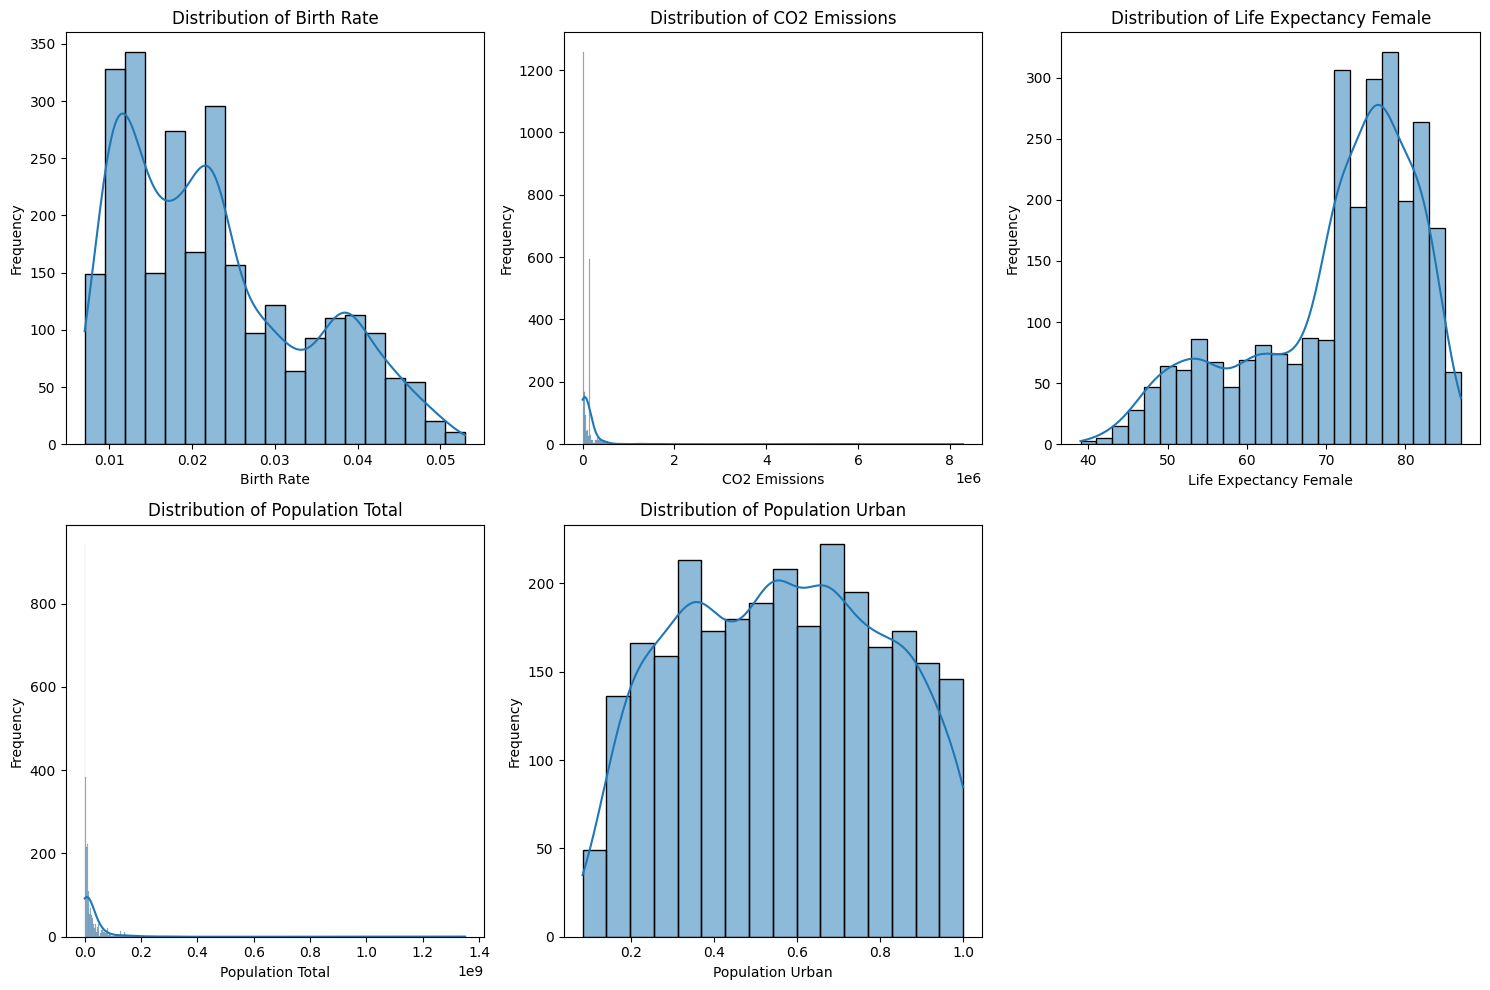

In [ ]:
numerical_cols_to_plot = [
    'Birth Rate',
    'CO2 Emissions',
    'Life Expectancy Female',
    'Population Total',
    'Population Urban'
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols_to_plot):
    plt.subplot(2, 3, i + 1) # Create a 2x3 grid of subplots
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
X = df_min_max_scaled

print("Features (X) for clustering:")
display(X.head())

Features (X) for clustering:


,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Country_United States,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,"Country_Venezuela, RB",Country_Vietnam,Country_Virgin Islands (U.S.),"Country_Yemen, Rep.",Country_Zambia,Country_Zimbabwe
0,0.282609,0.1232,0.010610,0.056276,0.499339,0.009895,0.003369,0.124424,0.005855,0.112082,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.934783,0.1232,0.001151,0.056276,0.499339,0.002746,0.000558,0.119816,0.002019,0.112082,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.782609,0.1232,0.000194,0.056276,0.499339,0.000724,0.000141,0.161290,0.001312,0.112082,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.434783,0.1232,0.000515,0.056276,0.499339,0.000670,0.000352,0.179724,0.015142,0.112082,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.847826,0.1232,0.000125,0.056276,0.499339,0.028313,0.000157,0.198157,0.001009,0.112082,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


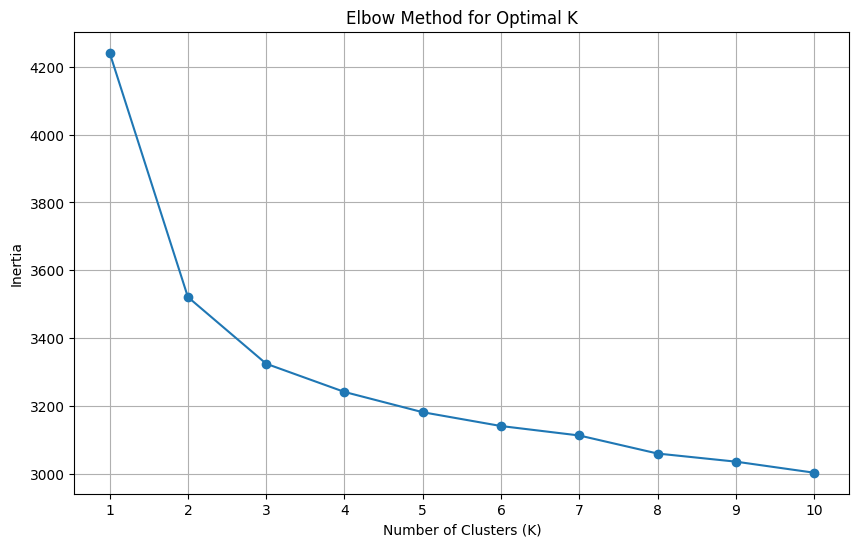

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create an empty list to store inertia values
inertia_values = []

# Define a range of cluster numbers to test
k_range = range(1, 11) # Testing from 1 to 10 clusters

# Loop through the range of cluster numbers
for k in k_range:
    # Initialize KMeans model
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init='auto')

    # Fit the model to the scaled data X
    kmeans_model.fit(X)

    # Append the inertia to the list
    inertia_values.append(kmeans_model.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [ ]:
optimal_k = 3 # Based on the Elbow Method plot from the previous step

# Initialize KMeans model with the optimal number of clusters
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')

# Fit the model to the scaled data X
kmeans_optimal.fit(X)

# Add the cluster labels as a new column named 'Cluster' to the df_processed DataFrame
df_processed['Cluster'] = kmeans_optimal.labels_

print(f"K-Means clustering applied with {optimal_k} clusters.")
print("First 5 rows of df_processed with new 'Cluster' column:")
display(df_processed.head())

K-Means clustering applied with 3 clusters.
First 5 rows of df_processed with new 'Cluster' column:


,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,"Country_Venezuela, RB",Country_Vietnam,Country_Virgin Islands (U.S.),"Country_Yemen, Rep.",Country_Zambia,Country_Zimbabwe,Cluster
0,0.020,0.489669,87931.0,39.999418,94.875676,26998.000000,5.479006e+10,0.035,60.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.050,0.489669,9542.0,39.999418,94.875676,7499.000000,9.129595e+09,0.034,22.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.043,0.489669,1617.0,39.999418,94.875676,1983.000000,2.359122e+09,0.043,15.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,0.027,0.489669,4276.0,39.999418,94.875676,1836.000000,5.788312e+09,0.047,152.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,0.046,0.489669,1041.0,39.999418,94.875676,77236.840896,2.610959e+09,0.051,12.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


In [ ]:
from sklearn.cluster import DBSCAN

# Initialize a DBSCAN model with eps=0.5 and min_samples=5
dbscan_model = DBSCAN(eps=0.5, min_samples=5)

# Fit the DBSCAN model to the scaled data X (df_min_max_scaled)
dbscan_model.fit(X)

# Add the cluster labels as a new column named 'DBSCAN_Cluster' to the df_processed DataFrame
df_processed['DBSCAN_Cluster'] = dbscan_model.labels_

# Get unique cluster labels, excluding noise points (-1)
unique_clusters = len(set(dbscan_model.labels_)) - (1 if -1 in dbscan_model.labels_ else 0)

print(f"Number of unique clusters found (excluding noise points): {unique_clusters}")
print("First 5 rows of df_processed with new 'DBSCAN_Cluster' column:")
display(df_processed.head())

Number of unique clusters found (excluding noise points): 214
First 5 rows of df_processed with new 'DBSCAN_Cluster' column:


,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Country_Uzbekistan,Country_Vanuatu,"Country_Venezuela, RB",Country_Vietnam,Country_Virgin Islands (U.S.),"Country_Yemen, Rep.",Country_Zambia,Country_Zimbabwe,Cluster,DBSCAN_Cluster
0,0.020,0.489669,87931.0,39.999418,94.875676,26998.000000,5.479006e+10,0.035,60.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,0.050,0.489669,9542.0,39.999418,94.875676,7499.000000,9.129595e+09,0.034,22.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,1
2,0.043,0.489669,1617.0,39.999418,94.875676,1983.000000,2.359122e+09,0.043,15.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,2
3,0.027,0.489669,4276.0,39.999418,94.875676,1836.000000,5.788312e+09,0.047,152.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,3
4,0.046,0.489669,1041.0,39.999418,94.875676,77236.840896,2.610959e+09,0.051,12.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,4


In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Initialize AgglomerativeClustering model with n_clusters=3, affinity='euclidean', and linkage='ward'
# Note: For versions of scikit-learn >= 1.2, 'affinity' is deprecated in favor of 'metric'.
# 'euclidean' is the default for 'metric' when 'linkage' is 'ward'.
agglomerative_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

# Fit the Agglomerative Clustering model to the scaled data X
# AgglomerativeClustering does not have a separate .fit() and .predict() for labels;
# it computes labels during fit_predict or fit and then labels_ attribute.
df_processed['Agglomerative_Cluster'] = agglomerative_model.fit_predict(X)

# Get unique cluster labels
unique_clusters_agglomerative = df_processed['Agglomerative_Cluster'].nunique()

print(f"Number of unique clusters found by Agglomerative Clustering: {unique_clusters_agglomerative}")
print("First 5 rows of df_processed with new 'Agglomerative_Cluster' column:")
display(df_processed.head())

Number of unique clusters found by Agglomerative Clustering: 3
First 5 rows of df_processed with new 'Agglomerative_Cluster' column:


,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Country_Vanuatu,"Country_Venezuela, RB",Country_Vietnam,Country_Virgin Islands (U.S.),"Country_Yemen, Rep.",Country_Zambia,Country_Zimbabwe,Cluster,DBSCAN_Cluster,Agglomerative_Cluster
0,0.020,0.489669,87931.0,39.999418,94.875676,26998.000000,5.479006e+10,0.035,60.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,2
1,0.050,0.489669,9542.0,39.999418,94.875676,7499.000000,9.129595e+09,0.034,22.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,1,1
2,0.043,0.489669,1617.0,39.999418,94.875676,1983.000000,2.359122e+09,0.043,15.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,2,1
3,0.027,0.489669,4276.0,39.999418,94.875676,1836.000000,5.788312e+09,0.047,152.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,3,2
4,0.046,0.489669,1041.0,39.999418,94.875676,77236.840896,2.610959e+09,0.051,12.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,4,1


In [ ]:
from sklearn.mixture import GaussianMixture

# Initialize GaussianMixture model with n_components=optimal_k (from KMeans Elbow Method)
gmm_model = GaussianMixture(n_components=optimal_k, random_state=42)

# Fit the GaussianMixture model to the scaled data X
gmm_model.fit(X)

# Predict the cluster labels for X
df_processed['GMM_Cluster'] = gmm_model.predict(X)

# Get unique cluster labels
unique_clusters_gmm = df_processed['GMM_Cluster'].nunique()

print(f"Number of unique clusters found by GMM: {unique_clusters_gmm}")
print("First 5 rows of df_processed with new 'GMM_Cluster' column:")
display(df_processed.head())

Number of unique clusters found by GMM: 3
First 5 rows of df_processed with new 'GMM_Cluster' column:


,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,"Country_Venezuela, RB",Country_Vietnam,Country_Virgin Islands (U.S.),"Country_Yemen, Rep.",Country_Zambia,Country_Zimbabwe,Cluster,DBSCAN_Cluster,Agglomerative_Cluster,GMM_Cluster
0,0.020,0.489669,87931.0,39.999418,94.875676,26998.000000,5.479006e+10,0.035,60.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,2,0
1,0.050,0.489669,9542.0,39.999418,94.875676,7499.000000,9.129595e+09,0.034,22.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,2,1,1,2
2,0.043,0.489669,1617.0,39.999418,94.875676,1983.000000,2.359122e+09,0.043,15.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,2,2,1,2
3,0.027,0.489669,4276.0,39.999418,94.875676,1836.000000,5.788312e+09,0.047,152.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,2,3,2,2
4,0.046,0.489669,1041.0,39.999418,94.875676,77236.840896,2.610959e+09,0.051,12.0,302.068503,...,0.0,0.0,0.0,0.0,0.0,0.0,2,4,1,2


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Extract KMeans cluster labels
kmeans_labels = df_processed['Cluster']

# Calculate Silhouette Score
silhouette_avg = silhouette_score(X, kmeans_labels)

# Calculate Davies-Bouldin Index
davies_bouldin_index = davies_bouldin_score(X, kmeans_labels)

print(f"KMeans Silhouette Score: {silhouette_avg:.4f}")
print(f"KMeans Davies-Bouldin Index: {davies_bouldin_index:.4f}")

KMeans Silhouette Score: 0.0885
KMeans Davies-Bouldin Index: 2.8789


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# 1. Extract DBSCAN cluster labels
dbscan_labels = df_processed['DBSCAN_Cluster']

# 2. Filter out noise points (clusters labeled -1)
# Create a boolean mask for non-noise points
non_noise_mask = dbscan_labels != -1

# Apply the mask to both the features X and the DBSCAN labels
X_filtered_dbscan = X[non_noise_mask]
dbscan_labels_filtered = dbscan_labels[non_noise_mask]

# 3. Check if there are at least two unique clusters remaining after removing noise points
unique_clusters_filtered = np.unique(dbscan_labels_filtered)

if len(unique_clusters_filtered) < 2:
    print("DBSCAN evaluation metrics cannot be calculated: Less than 2 unique clusters (excluding noise points) found.")
else:
    # 4. Calculate Silhouette Score
    silhouette_avg_dbscan = silhouette_score(X_filtered_dbscan, dbscan_labels_filtered)

    # 5. Calculate Davies-Bouldin Index
    davies_bouldin_index_dbscan = davies_bouldin_score(X_filtered_dbscan, dbscan_labels_filtered)

    # 6. Print the calculated metrics
    print(f"DBSCAN Silhouette Score (excluding noise): {silhouette_avg_dbscan:.4f}")
    print(f"DBSCAN Davies-Bouldin Index (excluding noise): {davies_bouldin_index_dbscan:.4f}")

DBSCAN Silhouette Score (excluding noise): 0.8065
DBSCAN Davies-Bouldin Index (excluding noise): 0.3520


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Extract Agglomerative cluster labels
agglomerative_labels = df_processed['Agglomerative_Cluster']

# Calculate Silhouette Score
silhouette_avg_agglomerative = silhouette_score(X, agglomerative_labels)

# Calculate Davies-Bouldin Index
davies_bouldin_index_agglomerative = davies_bouldin_score(X, agglomerative_labels)

print(f"Agglomerative Clustering Silhouette Score: {silhouette_avg_agglomerative:.4f}")
print(f"Agglomerative Clustering Davies-Bouldin Index: {davies_bouldin_index_agglomerative:.4f}")

Agglomerative Clustering Silhouette Score: 0.0805
Agglomerative Clustering Davies-Bouldin Index: 2.9718


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Extract GMM cluster labels
gmm_labels = df_processed['GMM_Cluster']

# Calculate Silhouette Score
silhouette_avg_gmm = silhouette_score(X, gmm_labels)

# Calculate Davies-Bouldin Index
davies_bouldin_index_gmm = davies_bouldin_score(X, gmm_labels)

print(f"GMM Silhouette Score: {silhouette_avg_gmm:.4f}")
print(f"GMM Davies-Bouldin Index: {davies_bouldin_index_gmm:.4f}")

GMM Silhouette Score: 0.0761
GMM Davies-Bouldin Index: 3.1659


## Summary:

### Data Analysis Key Findings

*   **DBSCAN** demonstrated significantly superior clustering performance with a Silhouette Score of 0.8065 and a Davies-Bouldin Index of 0.3520, indicating well-defined and separated clusters, including the effective handling of noise points. This method identified 214 unique clusters using default parameters (`eps=0.5` and `min_samples=5`).
*   In contrast, **KMeans**, **Agglomerative Clustering**, and **Gaussian Mixture Models (GMM)** showed comparatively poor performance, with Silhouette Scores of 0.0885, 0.0805, and 0.0761, respectively, and Davies-Bouldin Indices of 2.8789, 2.9718, and 3.1659, respectively. These metrics suggest that the fixed number of three clusters chosen for these models was not optimal, leading to overlapping or poorly separated clusters.

### Insights or Next Steps

*   DBSCAN is the most suitable clustering algorithm for this dataset due to its ability to identify density-based clusters and effectively manage noise, aligning with the inherent structure of the data.
*   Further analysis should focus on the characteristics of the 214 clusters identified by DBSCAN, including their size, density, and the attributes of the data points within each cluster, to derive actionable business insights.


In [45]:
pip install streamlit scikit-learn pandas numpy matplotlib


In [46]:
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

st.title("DBSCAN Clustering App")

uploaded_file = st.file_uploader("Upload CSV File", type=["csv"])

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
    st.write("Dataset Preview")
    st.write(df.head())

    eps = st.slider("Select EPS value", 0.1, 5.0, 0.5)
    min_samples = st.slider("Select Min Samples", 1, 20, 5)

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    model = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = model.fit_predict(scaled_data)

    df["Cluster"] = clusters

    st.write("Clustered Data")
    st.write(df)

    fig, ax = plt.subplots()
    ax.scatter(df.iloc[:, 0], df.iloc[:, 1], c=clusters)
    st.pyplot(fig)


2026-02-11 18:32:03.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-11 18:32:03.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-11 18:32:03.469 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-11 18:32:03.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-11 18:32:03.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-11 18:32:03.474 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-11 18:32:03.476 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-11 18:32:03.477 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [49]:
!streamlit run app.py


Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [ ]:
from flask import Flask, request, render_template
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

app = Flask(__name__)

@app.route("/", methods=["GET", "POST"])
def home():
    if request.method == "POST":
        file = request.files["file"]
        df = pd.read_csv(file)

        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df)

        model = DBSCAN(eps=0.5, min_samples=5)
        clusters = model.fit_predict(scaled_data)

        df["Cluster"] = clusters

        return df.to_html()

    return '''
    <form method="post" enctype="multipart/form-data">
        <input type="file" name="file">
        <input type="submit">
    </form>
    '''

if __name__ == "__main__":
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)
